# Generalization diagnostics: seed 7

Four controlled changes to the full-feature baseline on the existing 10% subset: lower learning rate, a smaller encoder, more dropout, and stronger weight decay. The completed baseline is reused as the control. This notebook reads loss histories and **validation** predictions only; no test predictions are used.

The primary comparison is minimum validation DockQ MSE, the checkpoint-selection criterion. Curves also show whether improvements persist until epoch 50. All results are from one training seed and the same validation split, so small differences need confirmation across seeds.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display, Markdown

GATE = Path.cwd() if (Path.cwd() / 'generalization_diagnostics_seed7').exists() else Path.cwd() / 'gate_run'
ROOT = GATE / 'generalization_diagnostics_seed7'
EXPORT = GATE / 'generalization_diagnostics_analysis'
EXPORT.mkdir(exist_ok=True)
matrix = json.loads((ROOT / 'matrix.json').read_text())
BASE = GATE / 'model_extensions_10pct_quick_no_apbs' / 'baseline_seed7'
NAMES = ['baseline', 'lower_lr', 'smaller_encoder', 'more_dropout', 'more_weight_decay']
LABELS = ['Baseline', 'Lower learning rate', 'Smaller encoder', 'More dropout', 'More weight decay']
SHORT = ['Baseline', 'Lower\nlearning rate', 'Smaller\nencoder', 'More\ndropout', 'More\nweight decay']
COLORS = ['black', '#0072B2', '#009E73', '#D55E00', '#CC79A7']
paths = {'baseline': BASE, **{k: ROOT / k for k in NAMES[1:]}}
label = dict(zip(NAMES, LABELS))
histories = {k: pd.read_csv(p / 'loss_history.csv') for k, p in paths.items()}
mpl.rcParams.update({'text.usetex': True, 'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'], 'mathtext.fontset': 'cm',
    'axes.labelsize': 23, 'xtick.labelsize': 17, 'ytick.labelsize': 17,
    'legend.fontsize': 17, 'axes.spines.top': True, 'axes.spines.right': True,
    'axes.linewidth': 1.1})
def save(fig, name):
    fig.savefig(EXPORT / (name + '.pdf'), bbox_inches='tight')
    fig.savefig(EXPORT / (name + '.png'), dpi=180, bbox_inches='tight')
    plt.show()

## Verify the comparison

The matrix must preserve the baseline arguments except for the declared diagnostic change, output path, and disabling test evaluation. All runs should finish the requested epochs, retain fixed loss weights, and have finite training/validation losses. Baseline validation predictions were not exported, so the baseline can be compared through its history but is excluded from prediction-level tables below.

In [2]:
def options(argv):
    result = {}; i = 0
    while i < len(argv):
        key = argv[i]; i += 1
        value = True
        if i < len(argv) and not argv[i].startswith('--'):
            value = argv[i]; i += 1
        result[key] = value
    return result
ref = options(matrix['diagnostic_reference']['argv'])
assert matrix['validation_only'] and matrix['apbs_enabled'] is False
original = json.loads((BASE.parent / 'matrix.json').read_text())
original_ref = next(r for r in original['runs'] if r['config']['name']=='baseline' and r['seed']==7)
assert options(original_ref['argv']) == ref
checks=[]
for run in matrix['runs']:
    name=run['config']['name']; opts=options(run['argv'])
    diff={k: opts.get(k) for k in set(ref)|set(opts) if opts.get(k)!=ref.get(k)}
    expected={**run['diagnostic_changes'], '--output-dir': run['output'], '--no-test-evaluation': True}
    assert diff==expected, (name, diff)
    assert run['seed']==7
    checks.append({'run':label[name], 'changes':str(run['diagnostic_changes'])})
for name,h in histories.items():
    assert h.epoch.tolist()==list(range(1,int(ref['--epochs'])+1)), name
    required=[c for c in h if c.startswith(('train_', 'val_'))]
    assert np.isfinite(h[required].to_numpy()).all(), name
    for term,weight in [('node_mse',1),('edge_attr_mse',1),('edge_presence_bce',.1),('target_mse',1)]:
        assert np.allclose(h['weight_'+term],weight), name
    if name!='baseline':
        assert h.filter(regex='^test_').isna().all().all()
display(pd.DataFrame(checks))
print('All five histories contain 50 complete epochs with fixed weights; diagnostic arguments match the planned changes.')
print('Baseline defaults in train_gate.py: LR 0.0003, hidden 64, latent 32, heads 4, dropout 0.1, weight decay 0.00001.')

,run,changes
0,Lower learning rate,{'--lr': '3e-5'}
1,Smaller encoder,"{'--hidden-dim': '32', '--latent-dim': '16', '..."
2,More dropout,{'--dropout': '0.3'}
3,More weight decay,{'--weight-decay': '0.001'}


All five histories contain 50 complete epochs with fixed weights; diagnostic arguments match the planned changes.
Baseline defaults in train_gate.py: LR 0.0003, hidden 64, latent 32, heads 4, dropout 0.1, weight decay 0.00001.


## Checkpoint quality and late-epoch stability

History MSE is the trainer's **mean of batch MSEs**, not an equal-target average. “Best epoch” is inferred from the minimum recorded validation DockQ MSE. A lower final loss is useful for stability, but it does not establish a better selected checkpoint. Training losses are collected with dropout active and weights changing during the epoch; their gap from validation is descriptive, not a perfectly matched evaluation.

In [3]:
rows=[]
for name,h in histories.items():
    best=h.loc[h.val_target_mse.idxmin()]; last=h.iloc[-1]
    rows.append(dict(run=name, best_epoch=int(best.epoch), best_val_mse=best.val_target_mse,
        final_val_mse=last.val_target_mse, final_train_mse=last.train_target_mse,
        final_gap=last.val_target_mse-last.train_target_mse,
        late10_val_mse=h.tail(10).val_target_mse.mean(),
        rebound_pct=100*(last.val_target_mse/best.val_target_mse-1),
        first_total=h.iloc[0].val_loss, final_total=last.val_loss))
summary=pd.DataFrame(rows).set_index('run').loc[NAMES]
summary['best_improvement_pct']=100*(1-summary.best_val_mse/summary.loc['baseline','best_val_mse'])
summary.to_csv(EXPORT/'history_summary.csv')
display(summary.round(5))

,best_epoch,best_val_mse,final_val_mse,final_train_mse,final_gap,late10_val_mse,rebound_pct,first_total,final_total,best_improvement_pct
run,,,,,,,,,,
baseline,5,0.07661,0.11181,0.02484,0.08697,0.11056,45.95010,2.35031,0.56322,0.00000
lower_lr,23,0.07898,0.08563,0.05558,0.03005,0.08535,8.41884,3.64773,1.04415,-3.09460
smaller_encoder,14,0.08204,0.09659,0.04963,0.04696,0.09743,17.73729,2.53132,0.96353,-7.09270
more_dropout,14,0.07591,0.08502,0.04253,0.04249,0.08494,12.00403,2.46924,0.77077,0.90988
more_weight_decay,5,0.07454,0.11576,0.02414,0.09162,0.11236,55.30510,2.34783,0.57361,2.69798


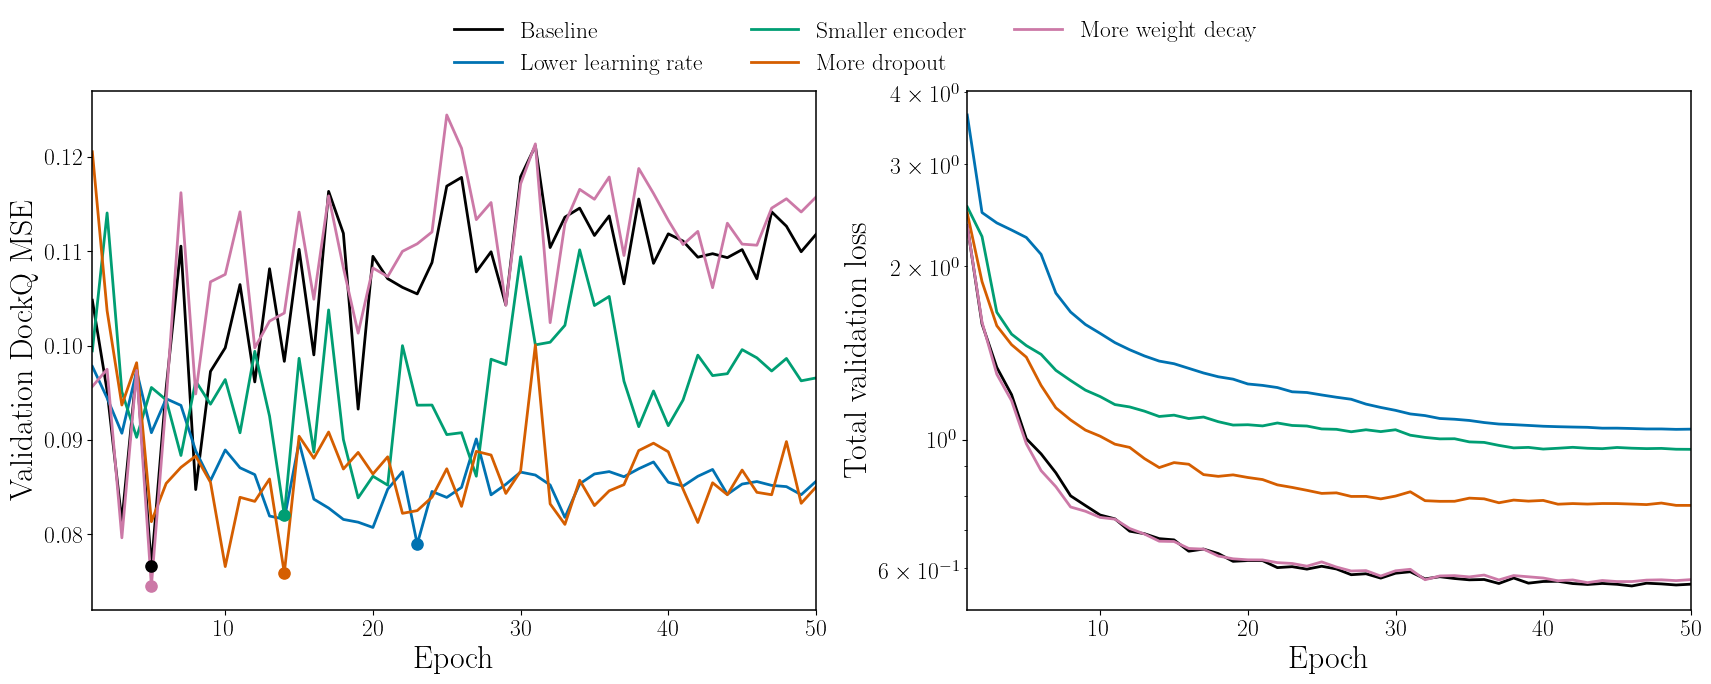

In [4]:
fig,axes=plt.subplots(1,2,figsize=(17,6.8),constrained_layout=True)
for name,color in zip(NAMES,COLORS):
    h=histories[name]; best=h.loc[h.val_target_mse.idxmin()]
    axes[0].plot(h.epoch,h.val_target_mse,color=color,label=label[name],lw=2)
    axes[0].scatter(best.epoch,best.val_target_mse,color=color,s=65,zorder=5)
    axes[1].plot(h.epoch,h.val_loss,color=color,lw=2)
axes[0].set_ylabel('Validation DockQ MSE')
axes[1].set_ylabel('Total validation loss')
axes[1].set_yscale('log')
for ax in axes: ax.set_xlabel('Epoch'); ax.set_xlim(1,50)
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside upper center',ncol=3,frameon=False)
save(fig,'validation_curves')

Dots identify the selected epochs. The total loss uses a logarithmic vertical scale to show its large decline. The panels below compare training (dashed) and validation (solid) DockQ error on shared axes; labels inside panels identify runs without plot titles.

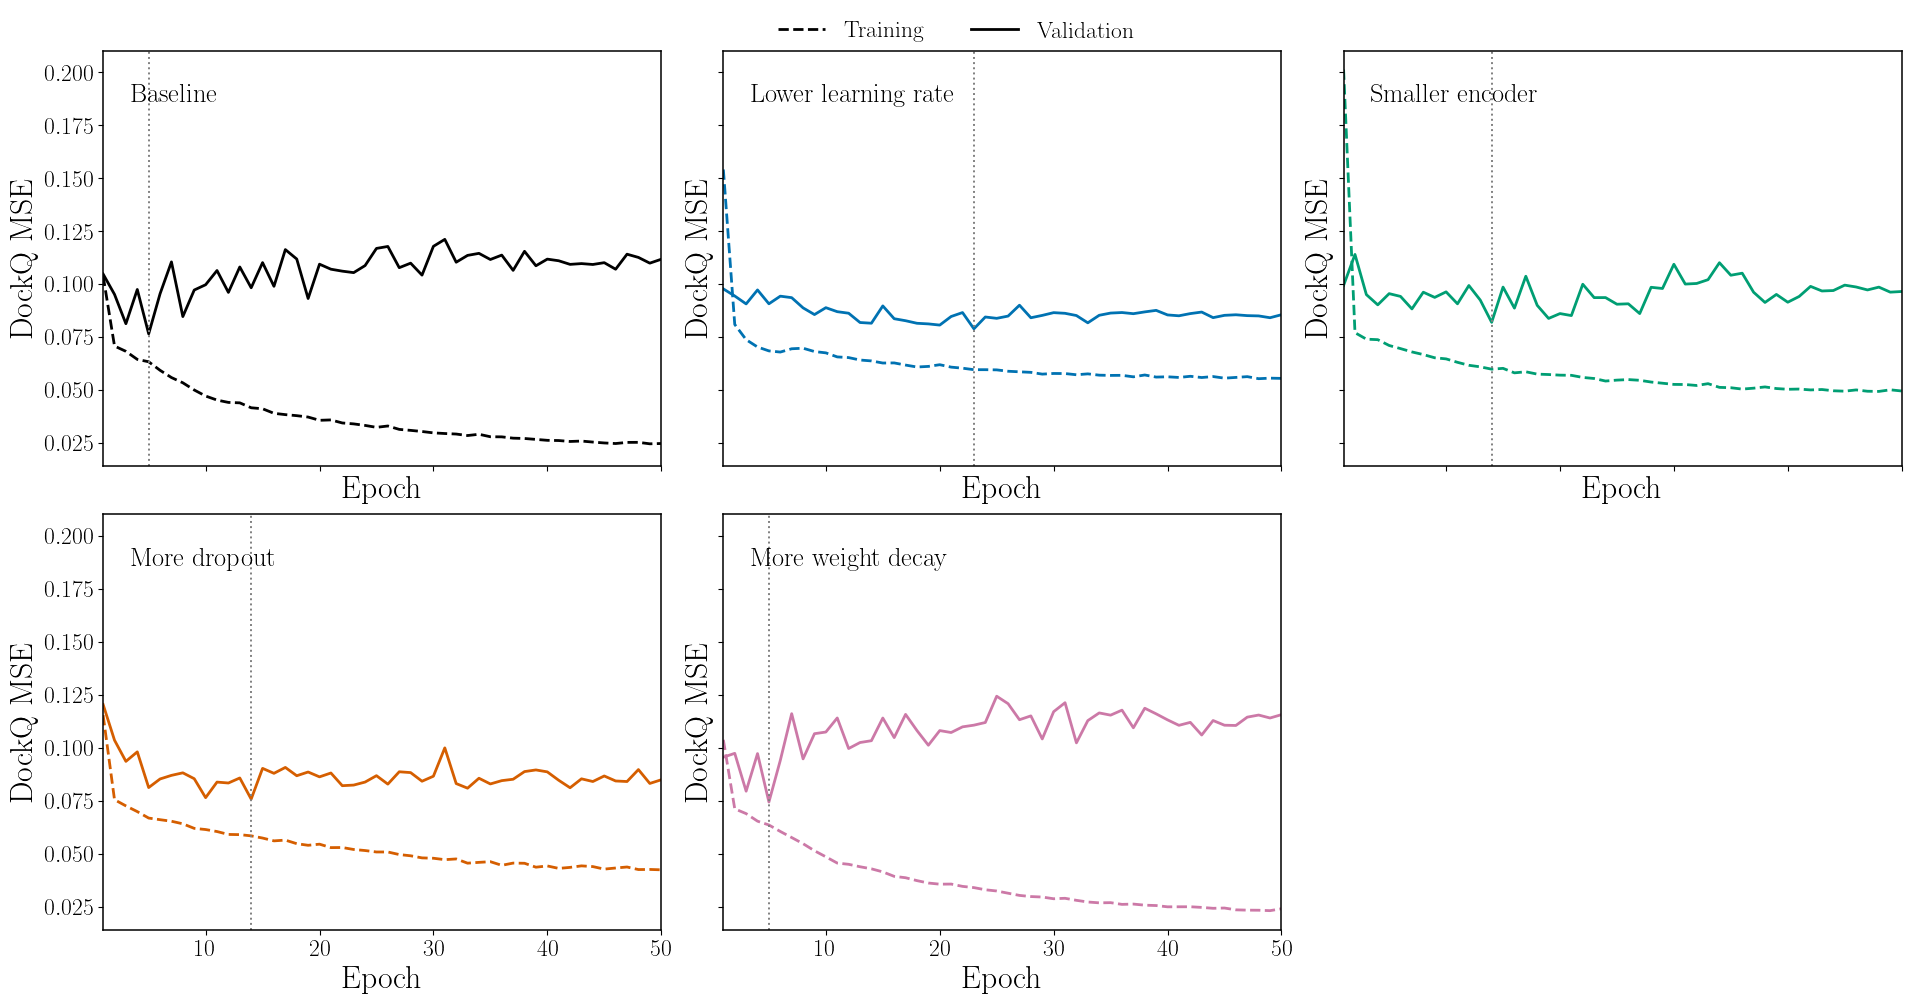

In [5]:
fig,axes=plt.subplots(2,3,figsize=(19,10),sharex=True,sharey=True,constrained_layout=True)
for ax,name,color in zip(axes.flat,NAMES,COLORS):
    h=histories[name]
    ax.plot(h.epoch,h.train_target_mse,'--',color=color,lw=2,label='Training')
    ax.plot(h.epoch,h.val_target_mse,color=color,lw=2,label='Validation')
    ax.axvline(summary.loc[name,'best_epoch'],color='gray',ls=':',lw=1.4)
    ax.text(.05,.92,label[name],transform=ax.transAxes,va='top',fontsize=19)
    ax.set_xlabel('Epoch'); ax.set_ylabel('DockQ MSE'); ax.set_xlim(1,50)
axes.flat[-1].axis('off')
fig.legend(*axes[0,0].get_legend_handles_labels(),loc='outside upper center',ncol=2,frameon=False)
save(fig,'train_validation_gap')

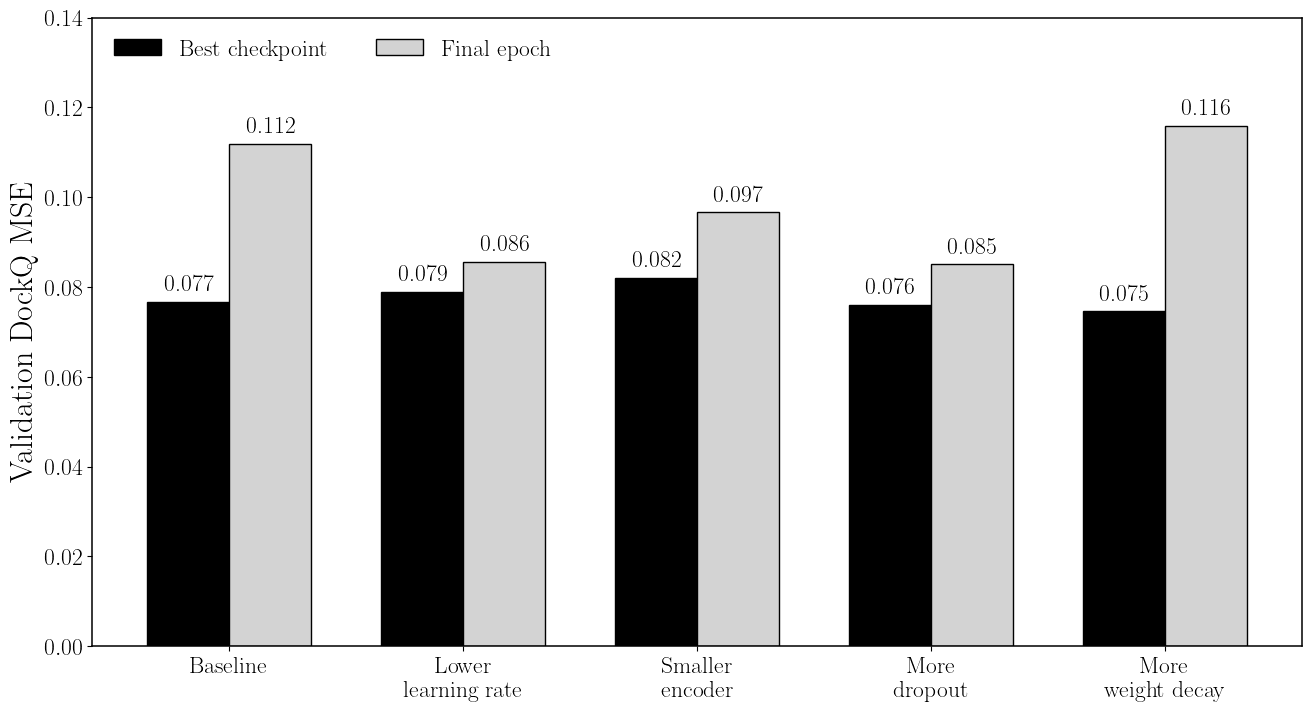

In [6]:
fig,ax=plt.subplots(figsize=(13,7),constrained_layout=True)
x=np.arange(len(NAMES)); width=.35
for shift,column,text,color in [(-.5,'best_val_mse','Best checkpoint','black'),(.5,'final_val_mse','Final epoch','lightgray')]:
    bars=ax.bar(x+shift*width,summary[column],width,color=color,edgecolor='black',label=text)
    ax.bar_label(bars,fmt='%.3f',padding=5,fontsize=17)
ax.set_xticks(x,SHORT); ax.set_ylabel('Validation DockQ MSE'); ax.set_ylim(0,.14)
ax.legend(frameon=False,loc='upper left',ncol=2)
save(fig,'best_vs_final_mse')

## Which objective drives the loss?

Fixed weights are node reconstruction ×1, edge-attribute reconstruction ×1, edge-presence BCE ×0.1, and DockQ MSE ×1. These curves diagnose numerical contributions; a larger scalar contribution alone does not establish that its gradients dominate or cause the generalization problem.

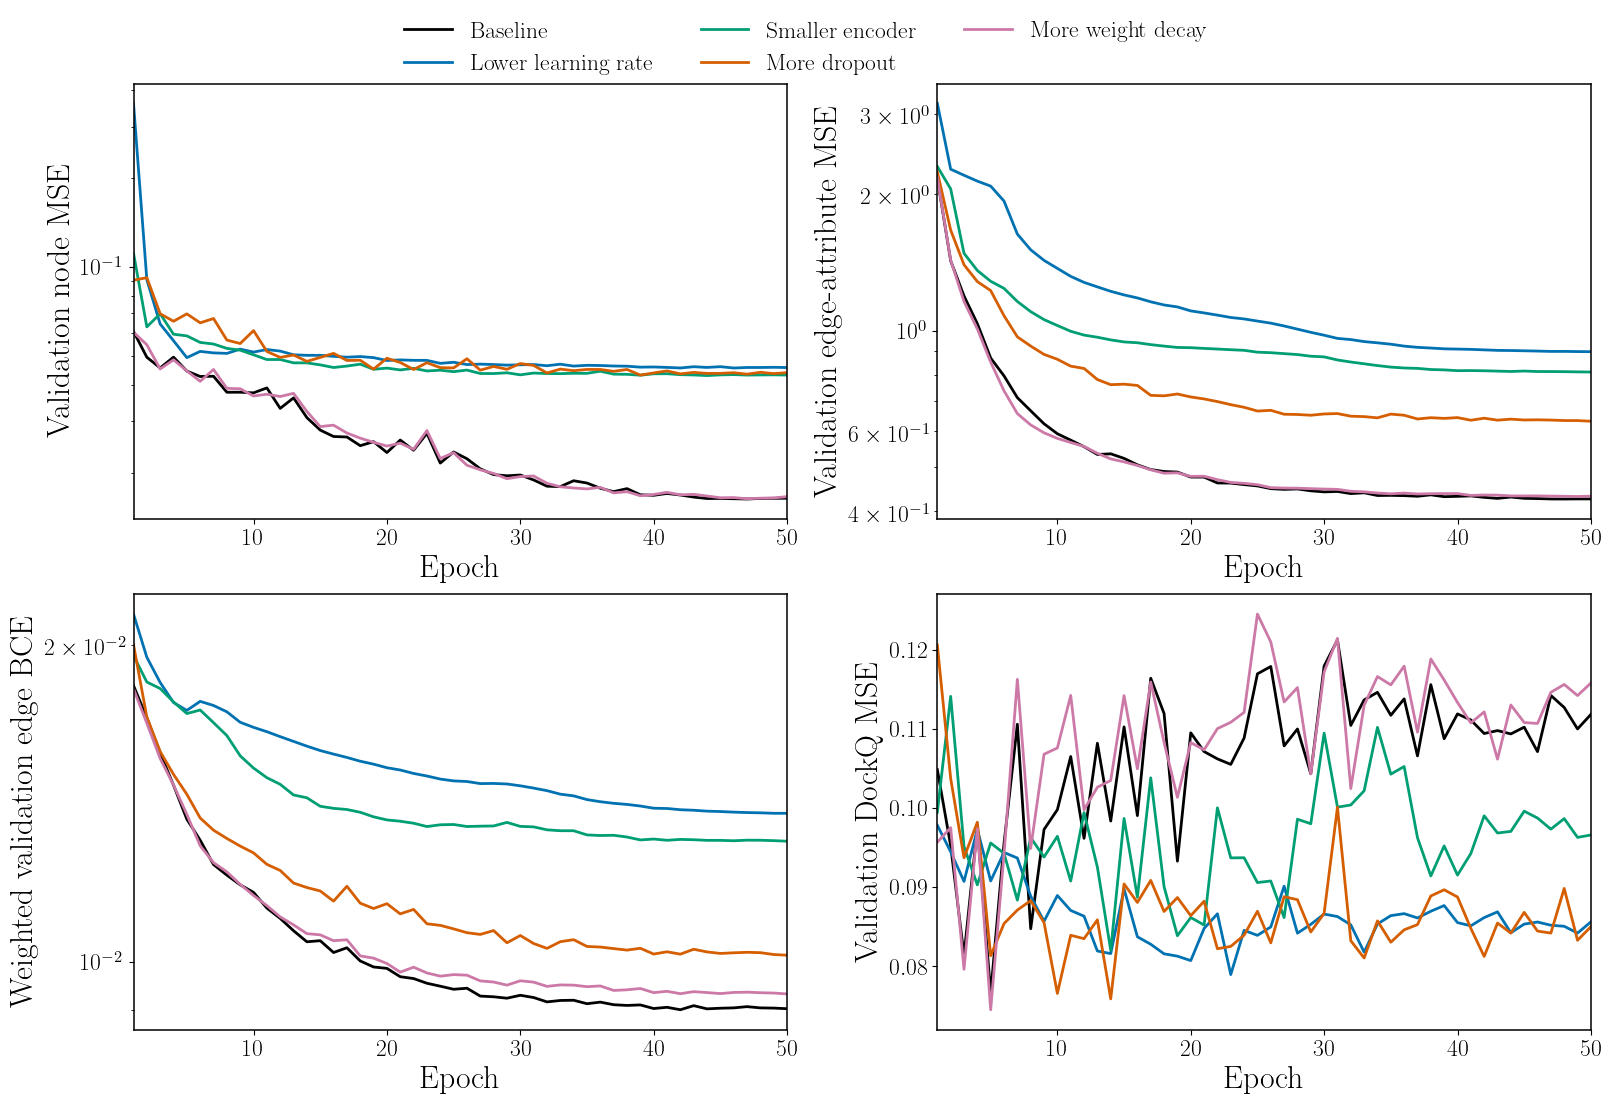

In [7]:
terms=[('node_mse',1,'Validation node MSE'),('edge_attr_mse',1,'Validation edge-attribute MSE'),
       ('edge_presence_bce',.1,'Weighted validation edge BCE'),('target_mse',1,'Validation DockQ MSE')]
fig,axes=plt.subplots(2,2,figsize=(16,11),constrained_layout=True)
for ax,(term,w,ylabel) in zip(axes.flat,terms):
    for name,color in zip(NAMES,COLORS):
        h=histories[name]; ax.plot(h.epoch,w*h['val_'+term],color=color,lw=2,label=label[name])
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_xlim(1,50)
    if term!='target_mse': ax.set_yscale('log')
fig.legend(*axes[0,0].get_legend_handles_labels(),loc='outside upper center',ncol=3,frameon=False)
save(fig,'validation_components')

## Validation predictions from the selected checkpoints

Check that all four files contain the same graphs, target labels, and validation targets from the frozen split. Prediction-level pooled MSE weights each graph equally; macro MSE and macro Spearman weight each target equally. These can differ from the history's mean of batch MSEs. Baseline predictions are unavailable for this split, so no baseline Spearman or paired baseline uncertainty is inferred.

In [8]:
predictions={}; reference=None; target_rows=[]; pred_rows=[]
split=json.loads((BASE.parent/'target_splits.json').read_text())['splits']
validation_targets=set(split['val']['targets'])
assert not validation_targets & set(split['train']['targets'])
assert not validation_targets & set(split['test']['targets'])
for name in NAMES[1:]:
    f=pd.read_csv(paths[name]/'validation_predictions.csv').sort_values(['target_id','graph_name']).reset_index(drop=True)
    assert not f.duplicated(['target_id','graph_name']).any()
    assert set(f.target_id)==validation_targets
    assert len(f)==split['val']['sample_count']
    assert np.isfinite(f[['true_target','predicted_target']]).all().all()
    identity=f[['target_id','graph_name','true_target']]
    if reference is None: reference=identity
    else: pd.testing.assert_frame_equal(reference,identity)
    predictions[name]=f
    for target,g in f.groupby('target_id'):
        y=g.true_target; p=g.predicted_target
        rho=spearmanr(y,p).statistic if y.nunique()>1 and p.nunique()>1 else np.nan
        target_rows.append(dict(run=name,target=target,n=len(g),mse=np.mean((p-y)**2),spearman=rho,bias=np.mean(p-y)))
    pred_rows.append(dict(run=name,n=len(f),targets=f.target_id.nunique(),pooled_mse=np.mean((f.predicted_target-f.true_target)**2)))
per_target=pd.DataFrame(target_rows)
pred_summary=pd.DataFrame(pred_rows).set_index('run').join(per_target.groupby('run').agg(macro_mse=('mse','mean'),macro_spearman=('spearman','mean'),defined_correlations=('spearman','count')))
pred_summary.to_csv(EXPORT/'validation_prediction_summary.csv')
per_target.to_csv(EXPORT/'validation_by_target.csv',index=False)
display(pred_summary.round(5))
print(f'Identical validation cohort: {len(reference)} graphs, {len(validation_targets)} targets. No test predictions read.')

,n,targets,pooled_mse,macro_mse,macro_spearman,defined_correlations
run,,,,,,
lower_lr,1132,10,0.07898,0.07876,0.47506,10
smaller_encoder,1132,10,0.08204,0.08227,0.45058,10
more_dropout,1132,10,0.07593,0.07464,0.40738,10
more_weight_decay,1132,10,0.07456,0.07374,0.47197,10


Identical validation cohort: 1132 graphs, 10 targets. No test predictions read.


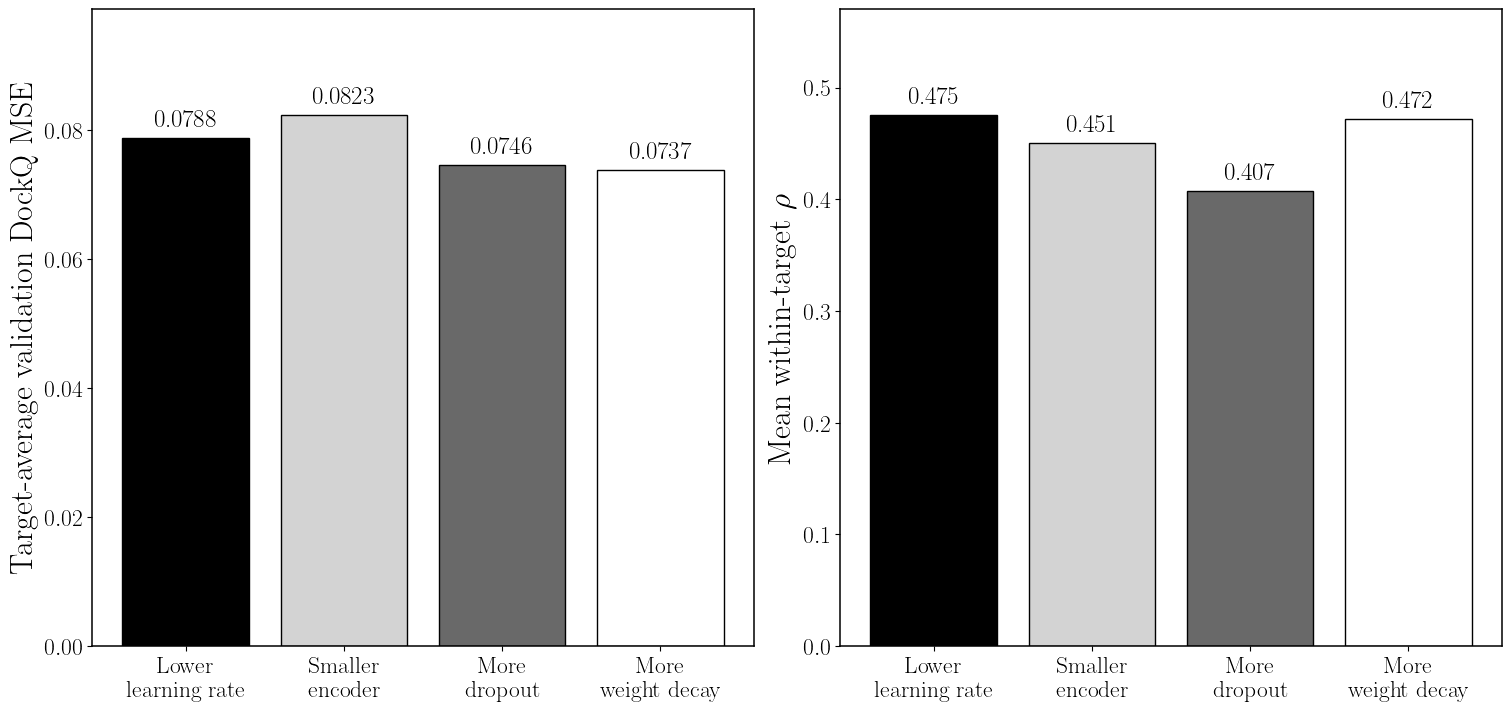

In [9]:
fig,axes=plt.subplots(1,2,figsize=(15,7),constrained_layout=True)
for ax,column,ylabel,fmt in zip(axes,['macro_mse','macro_spearman'],['Target-average validation DockQ MSE',r'Mean within-target $\rho$'],['%.4f','%.3f']):
    vals=pred_summary.loc[NAMES[1:],column]
    bars=ax.bar(np.arange(4),vals,color=['black','lightgray','dimgray','white'],edgecolor='black')
    ax.bar_label(bars,fmt=fmt,padding=5,fontsize=18)
    ax.set_xticks(np.arange(4),SHORT[1:]); ax.set_ylabel(ylabel)
    ax.set_ylim(min(0,vals.min()*1.2),vals.max()*1.2)
save(fig,'selected_checkpoint_validation_metrics')

## Interpretation and next steps

- **More dropout is the most promising stability change:** it preserves roughly baseline best-checkpoint accuracy while reducing the late validation-error rise. Confirm it with additional seeds before treating the small minimum-MSE advantage as reproducible.
- **Lower learning rate delays the best epoch and improves late stability**, but its best validation MSE is worse than baseline within this 50-epoch budget. This does not establish that it would win with a longer schedule.
- **A smaller encoder reduces the training/validation gap but worsens the best validation MSE.** Reduced capacity alone is not the solution in this run.
- **Stronger weight decay gives the lowest single observed validation MSE**, but the gain is small and the epoch-50 error is worse than baseline. It has not resolved late overfitting.
- Keep checkpoint selection and early stopping tied to **validation DockQ MSE**, rather than total reconstruction loss. The original baseline already selects its checkpoint on this metric; early stopping would mainly save compute after improvement stops.
- A focused next experiment is baseline versus dropout 0.3 across the same three seeds and frozen split. A dropout-plus-lower-LR combination is a separate hypothesis that this one-change-at-a-time sweep has not tested. Do not infer its benefit by adding the separate results.

No diagnostic completely eliminates the gap or demonstrates a large improvement in best-checkpoint validation accuracy. These results support improved regularization/stability, not a claim of improved performance on unseen test targets. Validation-guided selection across configurations can itself be optimistic; reserve a final test evaluation for the chosen protocol.

In [10]:
b=summary.loc['baseline']
lines=['Validation-only diagnostic summary (seed 7):']
for name in NAMES:
    r=summary.loc[name]
    lines.append(f"{label[name]}: best MSE {r.best_val_mse:.5f} at epoch {int(r.best_epoch)}; final {r.final_val_mse:.5f}; best-MSE improvement versus baseline {r.best_improvement_pct:+.2f}%.")
text='\n'.join(lines)
(EXPORT/'readout.txt').write_text(text+'\n')
print(text)

Validation-only diagnostic summary (seed 7):
Baseline: best MSE 0.07661 at epoch 5; final 0.11181; best-MSE improvement versus baseline +0.00%.
Lower learning rate: best MSE 0.07898 at epoch 23; final 0.08563; best-MSE improvement versus baseline -3.09%.
Smaller encoder: best MSE 0.08204 at epoch 14; final 0.09659; best-MSE improvement versus baseline -7.09%.
More dropout: best MSE 0.07591 at epoch 14; final 0.08502; best-MSE improvement versus baseline +0.91%.
More weight decay: best MSE 0.07454 at epoch 5; final 0.11576; best-MSE improvement versus baseline +2.70%.
